<a href="https://colab.research.google.com/github/Abhinaytechie/LangGraph/blob/main/MapReduce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langgraph langchain-groq

In [ ]:
from langchain_groq import ChatGroq
from google.colab import userdata


In [ ]:
llm =ChatGroq(groq_api_key=userdata.get('GROQ_API_KEY'),model="llama-3.3-70b-versatile")

In [ ]:
from typing_extensions import Annotated
from typing import List,TypedDict
from operator import add
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
from pydantic import BaseModel


In [ ]:
idea_topic_prompt="""Generate a list of 3 project ideas that are all related to this overall topic: {topic}."""
project_plan="According to the idea {idea}, generate a structured project overview,its real world usecase and developement plan"
best_project="Now from the list of {project_plan} ,select the single best project considering the factors like realworld usecase,final year project,resume worthy."

In [ ]:
class ProjectState(TypedDict):
  topic:str
  ideas:list
  project_plans:Annotated[list,add]
  best_project:str

class ProjectIdeaOutput(BaseModel):
  ideas:list[str]

In [ ]:
prompt=idea_topic_prompt.format(topic="AI")
output=llm.with_structured_output(ProjectIdeaOutput).invoke(prompt)
print(output)

ideas=['AI-powered chatbot for customer service', 'Deep learning model for image recognition', 'Natural language processing for text analysis']


In [ ]:
def project_ideas(state):
  prompt=idea_topic_prompt.format(topic=state['topic'])
  ideation=llm.with_structured_output(ProjectIdeaOutput).invoke(prompt)
  return {'ideas':ideation.ideas}


In [ ]:
from langgraph.types import Send

def crafting_process(state:ProjectState):
  return [Send("project_plan_craft",{"idea":i}) for i in state['ideas']]

In [ ]:
class ProjectPlanOutput(TypedDict):
  project_plans:str

def project_plan_craft(state:ProjectIdeaOutput):
  prompt=project_plan.format(idea=state['idea'])
  plans=llm.with_structured_output(ProjectPlanOutput).invoke(prompt)
  return {'project_plans':[plans['project_plans']]}

In [ ]:
prompt=project_plan.format(idea="Resume AI")
plans=llm.with_structured_output(ProjectPlanOutput).invoke(prompt)
print(plans)

{'project_plans': 'Resume AI Project Overview: The goal of Resume AI is to develop an artificial intelligence-powered resume screening tool that can help recruiters and hiring managers streamline their hiring process. Real-world use case: The tool can be used by companies to filter out unqualified candidates, saving time and resources. Development plan: The project will be developed in three phases - data collection, model training, and deployment. The first phase will involve collecting a large dataset of resumes and job descriptions. The second phase will involve training a machine learning model to match resumes with job descriptions. The third phase will involve deploying the model as a web application that can be used by recruiters and hiring managers.'}


In [ ]:
class BestProject(TypedDict):
  best_project:str

def best_project_selection(state:ProjectState):
  prompt=best_project.format(project_plan=state['project_plans'])
  best=llm.with_structured_output(BestProject).invoke(prompt)
  return {'best_project':best['best_project']}

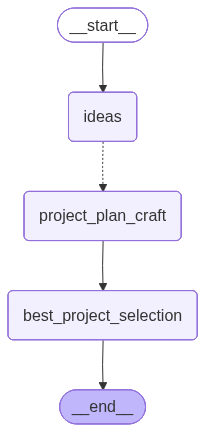

In [ ]:
graph=StateGraph(ProjectState)
graph.add_node("ideas",project_ideas)
graph.add_node("project_plan_craft",project_plan_craft)
graph.add_node("best_project_selection",best_project_selection)
graph.add_edge(START,"ideas")
graph.add_conditional_edges("ideas",crafting_process,["project_plan_craft"])
graph.add_edge("project_plan_craft","best_project_selection")
graph.add_edge("best_project_selection",END)
work=graph.compile()
display(Image(work.get_graph().draw_mermaid_png()))

In [ ]:
work.invoke({"topic":"AI"})

{'topic': 'AI',
 'ideas': ['Developing an AI-powered chatbot for customer service',
  'Creating an AI-driven image recognition system for medical diagnosis',
  'Designing an AI-based predictive maintenance platform for industrial equipment'],
 'project_plans': ['Project Overview: Developing an AI-powered chatbot for customer service\nReal-World Use Case: Implementing a chatbot to provide 24/7 support to customers, helping them with queries and issues related to products or services\nDevelopment Plan: Research and planning, designing the conversation flow, building and training the AI model, integrating with existing systems, testing and deployment, monitoring and maintenance',
  'Project Title: AI-Driven Image Recognition System for Medical Diagnosis\nProject Overview: The project aims to develop an AI-driven image recognition system for medical diagnosis, leveraging machine learning algorithms and deep learning techniques to analyze medical images and provide accurate diagnoses.\nReal